# External AI Report Augmentation

This notebook extends Spike Hunter V2 by integrating Binance AI Report features (opportunities/risks balance, sentiment, macro & flow flags) to enhance spike detection context.

Enhancements:
- Fetch & parse Binance AI report JSON into feature vector.
- Broadcast external features across bars newer than report time.
- Composite net bias feature merged with existing spike labels for exploratory correlation.
- Stale report handling (features zeroed if older than 8h).

Sections follow a generic scaffold but tailored to this topic.

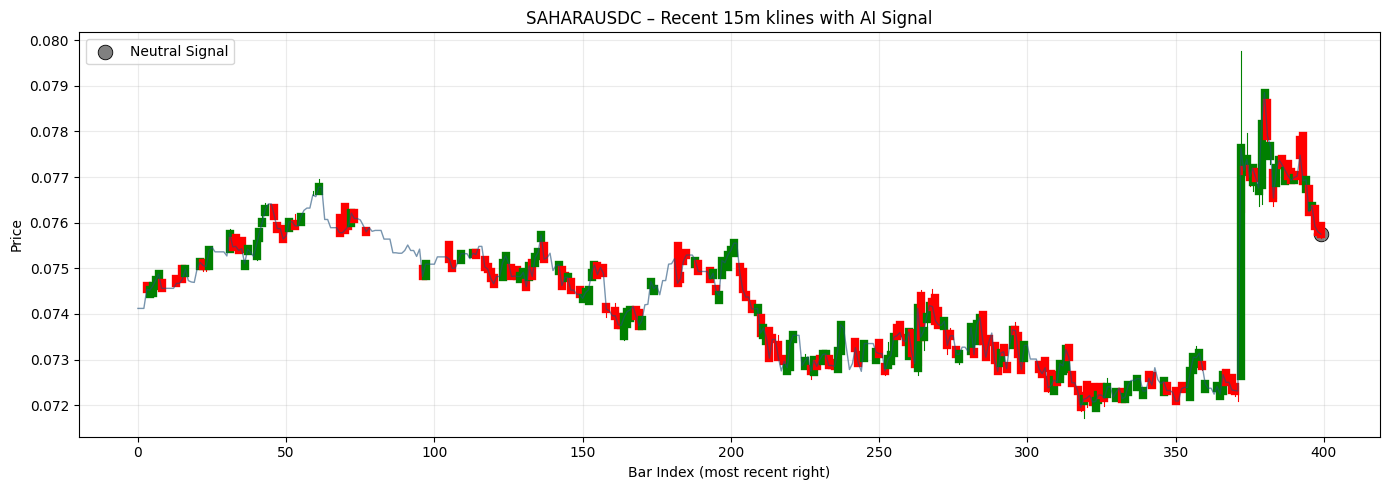

Signal: Neutral


In [ ]:
# Section 1: Setup Environment
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import time, math

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 80)

class BinanceAIReport:
    # Helper to derive base token from a trading symbol (simple heuristic)
    QUOTE_ASSETS = ["USDT", "USDC", "BUSD", "TRY", "EUR", "BTC", "ETH"]
    BINANCE_AI_ENDPOINT = "https://www.binance.com/bapi/bigdata/v3/friendly/bigdata/search/ai-report/report"
    QUOTE_ASSETS_INLINE = ["USDT", "USDC", "BUSD", "TRY", "EUR", "BTC", "ETH"]

    def __init__(self, symbol="GPSTRY", interval="15m", limit=400) -> None:
        self.symbol = symbol.upper()
        self.interval = interval
        self.limit = limit

    def base_token_from_symbol(self) -> str:
        """Infer base token by stripping common quote asset suffixes."""
        for q in self.QUOTE_ASSETS_INLINE:
            if self.symbol.endswith(q):
                base = self.symbol[: -len(q)]
                return base if base else self.symbol
        return self.symbol

    @staticmethod
    def count_points(mod_list):
        return sum(len(m.get("points", []) or []) for m in mod_list)

    @staticmethod
    def fetch_binance_klines(symbol: str, interval: str = "15m", limit: int = 500, end_time: int | None = None) -> pd.DataFrame:
        """Fetch klines from Binance and return a sorted DataFrame with standard OHLCV fields.
        Columns: timestamp, open, high, low, close, volume, quote_asset_volume, number_of_trades, taker_base, taker_quote
        """
        url = "https://api.binance.com/api/v3/klines"
        params = {"symbol": symbol.upper(), "interval": interval, "limit": limit}
        if end_time:
            params["endTime"] = end_time
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
        data = r.json()
        if not data:
            raise RuntimeError("Empty klines response")
        df = pd.DataFrame(
            data,
            columns=[
                "open_time","open","high","low","close","volume","close_time","quote_asset_volume","number_of_trades","taker_base","taker_quote","ignore",
            ],
        )
        num_cols = [
            "open","high","low","close","volume","quote_asset_volume","number_of_trades","taker_base","taker_quote",
        ]
        df[num_cols] = df[num_cols].astype(float)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        return df[[
            "timestamp","open","high","low","close","volume","quote_asset_volume","number_of_trades","taker_base","taker_quote",
        ]].sort_values("timestamp").reset_index(drop=True)

    # --- Binance AI Report Inline Logic ---
    def fetch_report(self) -> dict | None:
        """Fetch raw Binance AI report JSON for a given base token using POST request.
        Returns raw dictionary or None if network/scheme failure.
        """
        token = self.base_token_from_symbol()
        try:
            timestamp = int(time.time() * 1000)
            payload = {
                "lang": "en",
                "token": token.upper(),
                "symbol": self.symbol.upper(),
                "product": "web-spot",
                "timestamp": str(timestamp),
                "translateToken": None,
            }
            resp = requests.post(self.BINANCE_AI_ENDPOINT, json=payload, timeout=10)
            resp.raise_for_status()
            return resp.json()
        except Exception as e:  # pragma: no cover
            print("[AIReport] Fetch failed:", e)
            return None

    def extract_features(self, max_fresh_minutes: int = 8 * 60, normalize: bool = True) -> dict:
        """Extract heuristic external feature vector from raw report JSON."""
        report_json = self.fetch_report()
        if not report_json:
            return {"external_available": 0}
        data = report_json.get("data", {})
        original = (
            data.get("report", {}).get("original", {})
            if "report" in data
            else report_json.get("data", {}).get("original", {})
        )
        report_meta = original.get("reportMeta", {})
        modules = original.get("modules", []) or []
        update_ms = int(report_meta.get("updateAt", 0))
        age_minutes = (time.time() * 1000 - update_ms) / 60000.0 if update_ms else 1e9
        fresh = age_minutes <= max_fresh_minutes
        base = {
            "external_available": 1,
            "external_stale_flag": int(not fresh),
            "external_age_minutes": round(age_minutes, 2),
        }
        if not fresh:
            return base
        by_type = {}
        for m in modules:
            mtype = m.get("type", "")
            by_type.setdefault(mtype, []).append(m)
        opp_mods = by_type.get("opportunities", [])
        risk_mods = by_type.get("risks", [])
        comm_mods = by_type.get("community_sentiment", [])
        opp_count = self.count_points(opp_mods)
        risk_count = self.count_points(risk_mods)
        community_posts = 0
        if comm_mods:
            for m in comm_mods:
                for p in m.get("points", []) or []:
                    for ref in p.get("citationRefs", []) or []:
                        if ref.get("type") == "post":
                            community_posts += int(ref.get("count", 0))
        texts = []
        for m in modules:
            for p in m.get("points", []) or []:
                txt = p.get("content", "")
                if txt:
                    texts.append(txt)
            if m.get("overview"):
                texts.append(m["overview"])
        joined = " \n ".join(texts).lower()
        def kw_flag(*phrases):
            return int(any(ph.lower() in joined for ph in phrases))
        macd_bullish_flag = kw_flag("macd", "bullish crossover")
        ema_bearish_flag = kw_flag("ema7", "ema25", "ema99", "bearish")
        volatility_decreasing_flag = kw_flag("decreasing volatility")
        price_resilience_flag = kw_flag("resilience", "altcoins", "80-99%")
        outflow_flag = kw_flag("net outflow", "outflow")
        coinbase_premium_weak_flag = kw_flag("premium gaps", "weak demand", "coinbase")
        institutional_adoption_flag = kw_flag("institutional", "adoption", "survey")
        macro_headwind_flag = kw_flag("geopolitical", "trade tensions", "tariff")
        sentiment_mixed_flag = kw_flag("mixed sentiment", "mixed outlook")
        bull_support = macd_bullish_flag + institutional_adoption_flag + price_resilience_flag
        bear_pressure = ema_bearish_flag + outflow_flag + macro_headwind_flag
        net_bias = bull_support - bear_pressure
        bias_norm = math.tanh(net_bias) if normalize else net_bias
        ratio = (opp_count + 1) / (risk_count + 1)
        net_signal_score = opp_count - risk_count
        base.update({
            "opp_count": opp_count,
            "risk_count": risk_count,
            "opp_risk_ratio": round(ratio, 4),
            "net_signal_score": net_signal_score,
            "community_post_count": community_posts,
            "large_discussion_flag": int(community_posts >= 10),
            "external_net_bias": net_bias,
            "external_bias_normalized": round(bias_norm, 4),
            "macd_bullish_flag": macd_bullish_flag,
            "ema_bearish_flag": ema_bearish_flag,
            "sentiment_mixed_flag": sentiment_mixed_flag
        })
        return base

    def ai_report_signal(self, bias_thr: float = 0.5, opp_risk_thr: float = 1.2, net_score_thr: int = 1):
        features = self.extract_features()
        if not features or not features.get("external_available", 0):
            return 0
        bullish = (
            features.get("external_bias_normalized", 0) > bias_thr
            and features.get("opp_risk_ratio", 1) > opp_risk_thr
            and features.get("net_signal_score", 0) > net_score_thr
            and features.get("macd_bullish_flag", 0) == 1
        )
        bearish = (
            features.get("external_bias_normalized", 0) < -bias_thr
            and features.get("opp_risk_ratio", 1) < 1
            and features.get("net_signal_score", 0) < -net_score_thr
            and features.get("ema_bearish_flag", 0) == 1
        )
        if bullish:
            return 1
        if bearish:
            return -1
        return 0

    def plot_signal(self, bias_thr: float = 0.5, opp_risk_thr: float = 1.2, net_score_thr: int = 1, show_features: bool = True, width: float = 12.0):
        signal = self.ai_report_signal(bias_thr=bias_thr, opp_risk_thr=opp_risk_thr, net_score_thr=net_score_thr)
        features = self.extract_features()
        plt.figure(figsize=(width, 2.4))
        plt.bar(["Signal"], [signal], color=["green" if signal == 1 else "red" if signal == -1 else "gray"], width=0.6)
        plt.ylim(-1.2, 1.2)
        plt.title(f"AI Report Signal for {self.symbol}")
        plt.ylabel("1=Bullish  -1=Bearish  0=Neutral")
        plt.grid(axis="y", alpha=0.25)
        plt.xticks([])
        plt.tight_layout()
        plt.show()
        if show_features:
            core = [
                "external_age_minutes","opp_count","risk_count","opp_risk_ratio","net_signal_score","external_bias_normalized","macd_bullish_flag","ema_bearish_flag"
            ]
            print("Core features:")
            for k in core:
                print(f"  {k}: {features.get(k)}")
        return signal

    def plot_klines_with_signal(self, width: float = 14, height: float = 5, bias_thr: float = 0.5, opp_risk_thr: float = 1.2, net_score_thr: int = 1):
        """Plot recent klines (close + rudimentary candles) with AI signal overlay on last bar."""
        df = self.fetch_binance_klines(self.symbol, interval=self.interval, limit=self.limit)
        signal = self.ai_report_signal(bias_thr=bias_thr, opp_risk_thr=opp_risk_thr, net_score_thr=net_score_thr)
        # Basic candlestick (thin version)
        plt.figure(figsize=(width, height))
        x = range(len(df))
        colors = ["green" if df.loc[i, "close"] >= df.loc[i, "open"] else "red" for i in x]
        # Wicks
        for i in x:
            plt.plot([i, i], [df.loc[i, "low"], df.loc[i, "high"]], color=colors[i], linewidth=0.8)
        # Bodies
        for i in x:
            o = df.loc[i, "open"]; c = df.loc[i, "close"]
            plt.plot([i, i], [o, c], color=colors[i], linewidth=6)
        # Overlay close line
        plt.plot(x, df["close"], color="#1f4e79", linewidth=1.0, alpha=0.6)
        # Signal marker at last bar
        last_i = len(df) - 1
        last_close = df.loc[last_i, "close"]
        if signal == 1:
            plt.scatter([last_i], [last_close], marker="^", s=140, color="green", edgecolors="black", linewidths=0.6, label="Bullish Signal")
        elif signal == -1:
            plt.scatter([last_i], [last_close], marker="v", s=140, color="red", edgecolors="black", linewidths=0.6, label="Bearish Signal")
        else:
            plt.scatter([last_i], [last_close], marker="o", s=110, color="gray", edgecolors="black", linewidths=0.6, label="Neutral Signal")
        plt.title(f"{self.symbol} – Recent {self.interval} klines with AI Signal")
        plt.xlabel("Bar Index (most recent right)")
        plt.ylabel("Price")
        plt.grid(alpha=0.25)
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()
        return signal

# Quick inline smoke test
symbol = "SAHARAUSDC"
bar = BinanceAIReport(symbol)
signal = bar.plot_klines_with_signal()
print("Signal:", "Bullish" if signal==1 else "Bearish" if signal==-1 else "Neutral")